In [1]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    f1_score,
    roc_auc_score
)

from sklearn.preprocessing import label_binarize
import xgboost as xgb

## CLASSIFIER

In [2]:
# -------------------------
# Load FEATURES
# -------------------------

# Scaled (for Logistic Regression)
X_train_scaled = pd.read_csv("processed_data/X_train_scaled.csv")
X_val_scaled = pd.read_csv("processed_data/X_val_scaled.csv")
X_test_scaled = pd.read_csv("processed_data/X_test_scaled.csv")

# Unscaled (for tree models)
X_train_unscaled = pd.read_csv("processed_data/X_train_unscaled.csv")
X_val_unscaled = pd.read_csv("processed_data/X_val_unscaled.csv")
X_test_unscaled = pd.read_csv("processed_data/X_test_unscaled.csv")

# -------------------------
# Load TARGETS
# -------------------------

y_train = pd.read_csv("processed_data/y_train_clf.csv").squeeze()
y_val = pd.read_csv("processed_data/y_val_clf.csv").squeeze()
y_test = pd.read_csv("processed_data/y_test_clf.csv").squeeze()

print("Data loaded successfully")
print(X_train_scaled.shape, X_train_unscaled.shape)

Data loaded successfully
(283347, 51) (283347, 51)


In [3]:
import joblib

joblib.dump(X_train_unscaled.columns.tolist(), "processed_data/feature_columns.pkl")

print("✅ feature_columns.pkl saved")

✅ feature_columns.pkl saved


In [5]:
def evaluate_model(name, model, X_val, y_val):
    y_pred = model.predict(X_val)
    
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    
    # ROC-AUC (multi-class)
    y_prob = model.predict_proba(X_val)
    y_val_bin = label_binarize(y_val, classes=np.unique(y_val))
    
    roc_auc = roc_auc_score(y_val_bin, y_prob, multi_class='ovr')
    
    print(f"\n{name} Performance:")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    
    print("\nClassification Report:")
    print(classification_report(y_val, y_pred))
    
    return acc, f1, roc_auc

In [6]:
log_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

log_model.fit(X_train_scaled, y_train)

log_acc, log_f1, log_roc = evaluate_model(
    "Logistic Regression",
    log_model,
    X_val_scaled,
    y_val
)


Logistic Regression Performance:
Accuracy: 0.8179
F1 Score: 0.8622
ROC-AUC: 0.9467

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.75      0.80     11166
           1       0.18      0.77      0.29      2623
           2       0.99      0.84      0.91     46930

    accuracy                           0.82     60719
   macro avg       0.68      0.78      0.67     60719
weighted avg       0.93      0.82      0.86     60719



In [7]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train_unscaled, y_train)

rf_acc, rf_f1, rf_roc = evaluate_model(
    "Random Forest",
    rf_model,
    X_val_unscaled,
    y_val
)


Random Forest Performance:
Accuracy: 0.8154
F1 Score: 0.8604
ROC-AUC: 0.9531

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.75      0.80     11166
           1       0.17      0.75      0.28      2623
           2       0.99      0.83      0.91     46930

    accuracy                           0.82     60719
   macro avg       0.67      0.78      0.66     60719
weighted avg       0.93      0.82      0.86     60719



In [8]:
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train_unscaled, y_train)

xgb_acc, xgb_f1, xgb_roc = evaluate_model(
    "XGBoost",
    xgb_model,
    X_val_unscaled,
    y_val
)


XGBoost Performance:
Accuracy: 0.9531
F1 Score: 0.9373
ROC-AUC: 0.9866

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94     11166
           1       0.72      0.08      0.14      2623
           2       0.97      1.00      0.98     46930

    accuracy                           0.95     60719
   macro avg       0.86      0.68      0.69     60719
weighted avg       0.94      0.95      0.94     60719



adjusted_capacity                 0.272121
loan_to_income                    0.105742
requested_amount_log              0.082575
current_emi_amount                0.080961
requested_tenure                  0.057692
employment_type_government        0.037482
employment_type_self_employed     0.032414
credit_score                      0.030256
expense_ratio                     0.027154
monthly_salary_log                0.026617
employment_type_private           0.023438
monthly_rent                      0.022024
emi_scenario_vehicle_emi          0.020811
credit_utilization                0.018672
dti_ratio                         0.018221
years_of_employment               0.017350
bank_balance_log                  0.017316
emi_scenario_personal_loan_emi    0.014109
total_expenses                    0.014082
credit_dti_interaction            0.010979
dtype: float32


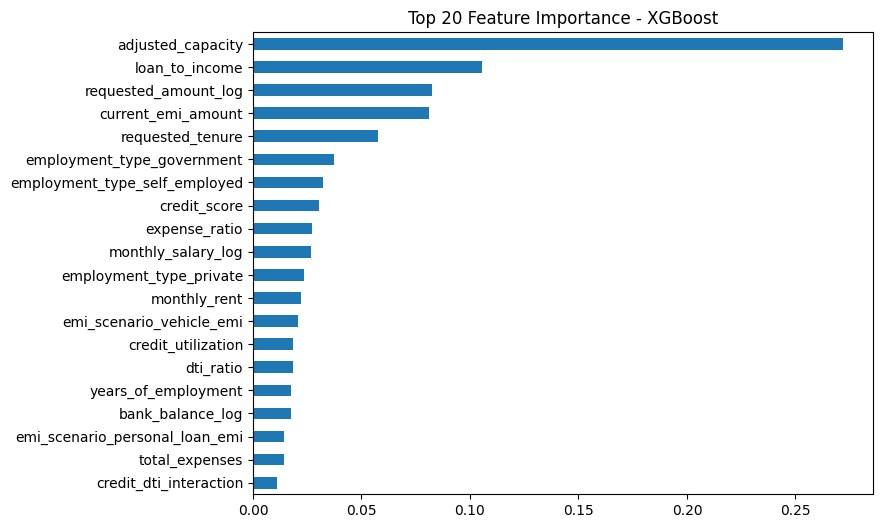

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train_unscaled.columns
).sort_values(ascending=False)

# Show top 20
print(importance.head(20))

# Plot
importance.head(20).plot(kind='barh', figsize=(8,6))
plt.title("Top 20 Feature Importance - XGBoost")
plt.gca().invert_yaxis()
plt.show()

In [10]:
import numpy as np

y_pred = xgb_model.predict(X_val_unscaled)

print("Predicted distribution:")
print(pd.Series(y_pred).value_counts(normalize=True))

print("\nActual distribution:")
print(pd.Series(y_val).value_counts(normalize=True))

Predicted distribution:
2    0.797213
0    0.197928
1    0.004858
Name: proportion, dtype: float64

Actual distribution:
0
2    0.772905
0    0.183896
1    0.043199
Name: proportion, dtype: float64


In [11]:
from collections import Counter

# Compute weights
counter = Counter(y_train)
total = sum(counter.values())

class_weights = {
    cls: total / count for cls, count in counter.items()
}

# Convert to sample weights
sample_weights = y_train.map(class_weights)

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss'
)

xgb_model.fit(
    X_train_unscaled,
    y_train,
    sample_weight=sample_weights
)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [13]:
y_pred = xgb_model.predict(X_val_unscaled)
y_prob = xgb_model.predict_proba(X_val_unscaled)

In [14]:
from sklearn.metrics import classification_report, accuracy_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np

# Accuracy & F1
acc = accuracy_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred, average='weighted')

# ROC-AUC
y_val_bin = label_binarize(y_val, classes=np.unique(y_val))
roc_auc = roc_auc_score(y_val_bin, y_prob, multi_class='ovr')

print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_pred))

Accuracy: 0.8863
F1 Score: 0.9131
ROC-AUC: 0.9820

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.85      0.90     11166
           1       0.27      0.93      0.42      2623
           2       1.00      0.89      0.94     46930

    accuracy                           0.89     60719
   macro avg       0.75      0.89      0.76     60719
weighted avg       0.96      0.89      0.91     60719



In [15]:
import pandas as pd

y_pred = xgb_model.predict(X_val_unscaled)

pd.crosstab(y_val, y_pred)

col_0,0,1,2
0,,,
0,9452,1685,29
1,149,2439,35
2,176,4827,41927


In [16]:
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
import xgboost as xgb

# =========================
# 1. COMPUTE CLASS WEIGHTS
# =========================
counter = Counter(y_train)
total = sum(counter.values())

class_weights = {
    cls: total / count for cls, count in counter.items()
}

# 🔥 Reduce class 1 aggressiveness
class_weights[1] = class_weights[1] * 0.6

# Convert to sample weights
sample_weights = y_train.map(class_weights)

# =========================
# 2. DEFINE BASE MODEL
# =========================
xgb_base = xgb.XGBClassifier(
    random_state=42,
    eval_metric='mlogloss'
)

# =========================
# 3. PARAM GRID (SMALL & SAFE)
# =========================
param_grid = {
    'max_depth': [4, 5],
    'learning_rate': [0.05, 0.08],
    'n_estimators': [100, 120],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

# =========================
# 4. GRID SEARCH
# =========================
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(
    X_train_unscaled,
    y_train,
    sample_weight=sample_weights
)

# Best model
best_model = grid_search.best_estimator_

print("✅ Best Parameters:", grid_search.best_params_)

# =========================
# 5. PREDICT
# =========================
y_pred = best_model.predict(X_val_unscaled)
y_prob = best_model.predict_proba(X_val_unscaled)

# =========================
# 6. EVALUATION
# =========================
acc = accuracy_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred, average='weighted')

y_val_bin = label_binarize(y_val, classes=np.unique(y_val))
roc_auc = roc_auc_score(y_val_bin, y_prob, multi_class='ovr')

print("\n=== GRID SEARCH XGBOOST PERFORMANCE ===")
print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_pred))

# =========================
# 7. DISTRIBUTION CHECK
# =========================
print("\nPredicted distribution:")
print(pd.Series(y_pred).value_counts(normalize=True))

print("\nActual distribution:")
print(pd.Series(y_val).value_counts(normalize=True))

Fitting 3 folds for each of 8 candidates, totalling 24 fits
✅ Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.08, 'max_depth': 5, 'n_estimators': 120, 'subsample': 0.8}

=== GRID SEARCH XGBOOST PERFORMANCE ===
Accuracy: 0.9032
F1 Score: 0.9225
ROC-AUC: 0.9788

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.91      0.92     11166
           1       0.30      0.83      0.44      2623
           2       1.00      0.91      0.95     46930

    accuracy                           0.90     60719
   macro avg       0.74      0.88      0.77     60719
weighted avg       0.96      0.90      0.92     60719


Predicted distribution:
2    0.701807
0    0.178972
1    0.119221
Name: proportion, dtype: float64

Actual distribution:
0
2    0.772905
0    0.183896
1    0.043199
Name: proportion, dtype: float64


In [17]:
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
import xgboost as xgb

# =========================
# 1. COMPUTE CLASS WEIGHTS
# =========================
counter = Counter(y_train)
total = sum(counter.values())
class_weights = {
    cls: total / count for cls, count in counter.items()
}

# 🔥 BOOST minority class (Class 1) instead of reducing
class_weights[1] = class_weights[1] * 2.5

# Convert to sample weights
sample_weights = y_train.map(class_weights)

# =========================
# 2. DEFINE BASE MODEL
# =========================
xgb_base = xgb.XGBClassifier(
    random_state=42,
    eval_metric='mlogloss'
)

# =========================
# 3. PARAM GRID (SMALL & SAFE)
# =========================
param_grid = {
    'max_depth': [4, 5],
    'learning_rate': [0.05, 0.08],
    'n_estimators': [100, 120],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

# =========================
# 4. GRID SEARCH WITH STRATIFIED CV
# =========================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='f1_macro',  # Changed from f1_weighted
    cv=cv,  # Stratified CV
    verbose=1,
    n_jobs=-1
)

grid_search.fit(
    X_train_unscaled,
    y_train,
    sample_weight=sample_weights
)

# Best model
best_model = grid_search.best_estimator_
print("✅ Best Parameters:", grid_search.best_params_)

# =========================
# 5. PREDICT
# =========================
y_pred = best_model.predict(X_val_unscaled)
y_prob = best_model.predict_proba(X_val_unscaled)

# =========================
# 6. EVALUATION
# =========================
acc = accuracy_score(y_val, y_pred)
f1_weighted = f1_score(y_val, y_pred, average='weighted')
f1_macro = f1_score(y_val, y_pred, average='macro')

y_val_bin = label_binarize(y_val, classes=np.unique(y_val))
roc_auc = roc_auc_score(y_val_bin, y_prob, multi_class='ovr')

print("\n=== GRID SEARCH XGBOOST PERFORMANCE ===")
print(f"Accuracy: {acc:.4f}")
print(f"F1 Score (Weighted): {f1_weighted:.4f}")
print(f"F1 Score (Macro): {f1_macro:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_pred))

# =========================
# 7. CLASS 1 SPECIFIC METRICS
# =========================
report_dict = classification_report(y_val, y_pred, output_dict=True)
print("\n🎯 CLASS 1 (Minority) PERFORMANCE:")
print(f"  Precision: {report_dict['1']['precision']:.4f}")
print(f"  Recall: {report_dict['1']['recall']:.4f}")
print(f"  F1-Score: {report_dict['1']['f1-score']:.4f}")

# =========================
# 8. DISTRIBUTION CHECK
# =========================
print("\nPredicted distribution:")
print(pd.Series(y_pred).value_counts(normalize=True))
print("\nActual distribution:")
print(pd.Series(y_val).value_counts(normalize=True))

Fitting 5 folds for each of 8 candidates, totalling 40 fits
✅ Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.08, 'max_depth': 5, 'n_estimators': 120, 'subsample': 0.8}

=== GRID SEARCH XGBOOST PERFORMANCE ===
Accuracy: 0.8062
F1 Score (Weighted): 0.8599
F1 Score (Macro): 0.6700
ROC-AUC: 0.9771

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.67      0.80     11166
           1       0.18      0.98      0.31      2623
           2       1.00      0.83      0.91     46930

    accuracy                           0.81     60719
   macro avg       0.72      0.83      0.67     60719
weighted avg       0.96      0.81      0.86     60719


🎯 CLASS 1 (Minority) PERFORMANCE:
  Precision: 0.1815
  Recall: 0.9790
  F1-Score: 0.3063

Predicted distribution:
2    0.640738
1    0.232975
0    0.126287
Name: proportion, dtype: float64

Actual distribution:
0
2    0.772905
0    0.183896
1    0.043199
Name: proportion, dtype: flo

In [18]:
from imblearn.over_sampling import SMOTE

# Oversample Class 1 to 15% of dataset
smote = SMOTE(sampling_strategy={1: int(len(y_train) * 0.15)}, random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_unscaled, y_train)

# Now use REDUCED weights (because you have more samples)
counter_resampled = Counter(y_resampled)
total_resampled = sum(counter_resampled.values())
class_weights_resampled = {
    cls: total_resampled / count for cls, count in counter_resampled.items()
}
# Light boost, not heavy
class_weights_resampled[1] = class_weights_resampled[1] * 1.2

sample_weights_resampled = pd.Series(y_resampled).map(class_weights_resampled)

# Grid search on resampled data
grid_search.fit(X_resampled, y_resampled, sample_weight=sample_weights_resampled)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8], 'learning_rate': [0.05, 0.08], 'max_depth': [4, 5], 'n_estimators': [100, 120], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time f

✅ Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.08, 'max_depth': 5, 'n_estimators': 120, 'subsample': 0.8}

TEST SET PERFORMANCE
Accuracy: 0.9241
F1 Score (Weighted): 0.9324
F1 Score (Macro): 0.7752
ROC-AUC: 0.9774

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.95      0.91     11167
           1       0.35      0.61      0.45      2623
           2       1.00      0.93      0.96     46930

    accuracy                           0.92     60720
   macro avg       0.74      0.83      0.78     60720
weighted avg       0.95      0.92      0.93     60720


🎯 CLASS 1 (Minority) PERFORMANCE:
  Precision: 0.3541
  Recall: 0.6077
  F1-Score: 0.4475

DISTRIBUTION ANALYSIS
Predicted distribution:
0    0.200082
1    0.074127
2    0.725791
Name: proportion, dtype: float64

Actual distribution:
0
0    0.183910
1    0.043198
2    0.772892
Name: proportion, dtype: float64

CONFUSION MATRIX
[[10660   450    57]
 [  871  1594

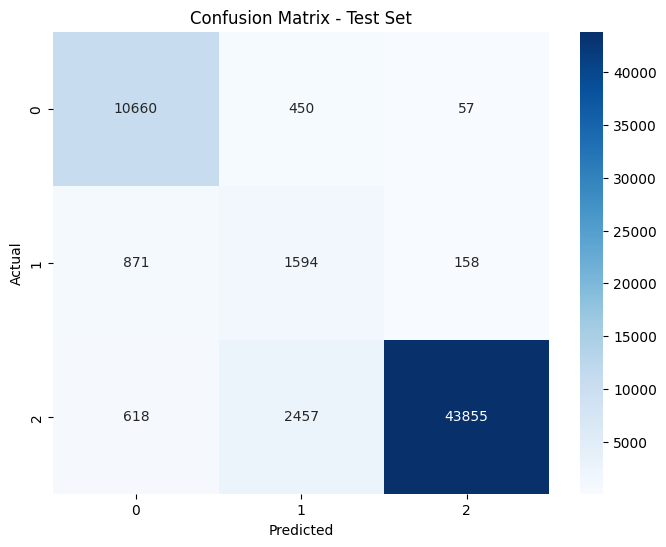

In [19]:
# =========================
# GET BEST MODEL FROM GRID SEARCH
# =========================
best_model = grid_search.best_estimator_
print("✅ Best Parameters:", grid_search.best_params_)

# =========================
# PREDICT ON TEST SET
# =========================
y_test_pred = best_model.predict(X_test_unscaled)
y_test_prob = best_model.predict_proba(X_test_unscaled)

# =========================
# EVALUATION METRICS
# =========================
acc = accuracy_score(y_test, y_test_pred)
f1_weighted = f1_score(y_test, y_test_pred, average='weighted')
f1_macro = f1_score(y_test, y_test_pred, average='macro')

y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
roc_auc = roc_auc_score(y_test_bin, y_test_prob, multi_class='ovr')

print("\n" + "="*50)
print("TEST SET PERFORMANCE")
print("="*50)
print(f"Accuracy: {acc:.4f}")
print(f"F1 Score (Weighted): {f1_weighted:.4f}")
print(f"F1 Score (Macro): {f1_macro:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

# =========================
# CLASS 1 SPECIFIC METRICS
# =========================
report_dict = classification_report(y_test, y_test_pred, output_dict=True)
print("\n🎯 CLASS 1 (Minority) PERFORMANCE:")
print(f"  Precision: {report_dict['1']['precision']:.4f}")
print(f"  Recall: {report_dict['1']['recall']:.4f}")
print(f"  F1-Score: {report_dict['1']['f1-score']:.4f}")

# =========================
# DISTRIBUTION CHECK
# =========================
print("\n" + "="*50)
print("DISTRIBUTION ANALYSIS")
print("="*50)
print("Predicted distribution:")
print(pd.Series(y_test_pred).value_counts(normalize=True).sort_index())
print("\nActual distribution:")
print(pd.Series(y_test).value_counts(normalize=True).sort_index())

# =========================
# CONFUSION MATRIX
# =========================
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)
print("\n" + "="*50)
print("CONFUSION MATRIX")
print("="*50)
print(cm)
print("\nRow = Actual, Column = Predicted")

# Optional: Visual confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[0, 1, 2], yticklabels=[0, 1, 2])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Test Set')
plt.show()

In [37]:
import joblib

joblib.dump(best_model, "processed_data/xgb_model.pkl")

print("✅ XGBoost model saved")

✅ XGBoost model saved


In [38]:
from xgboost import XGBClassifier
model: XGBClassifier = joblib.load("processed_data/xgb_model.pkl")
print(input_df.T)
print(model.feature_importances_)

                                               0
age                                           35
years_of_employment                            7
monthly_rent                                   0
family_size                                    3
school_fees                                 2000
college_fees                                   0
travel_expenses                             3000
groceries_utilities                         6000
other_monthly_expenses                      4000
current_emi_amount                          5000
credit_score                                 750
requested_tenure                              36
total_expenses                             15000
dti_ratio                               0.222222
monthly_salary_log                     11.407576
requested_amount_log                   12.206078
bank_balance_log                       12.206078
loan_to_income                          2.222198
available_for_emi                          70000
expense_ratio       

## MLFLOW INTEGRATION FOR CLASSIFIER

In [22]:
import mlflow
import mlflow.sklearn

mlflow.set_experiment("EMI_Predict_Classification")

Traceback (most recent call last):
  File "c:\Users\nlalr\AppData\Local\Programs\Python\Python314\Lib\site-packages\mlflow\store\tracking\file_store.py", line 383, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
  File "c:\Users\nlalr\AppData\Local\Programs\Python\Python314\Lib\site-packages\mlflow\store\tracking\file_store.py", line 481, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
  File "c:\Users\nlalr\AppData\Local\Programs\Python\Python314\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1670, in _read_yaml
    return _read_helper(root, file_name, attempts_remaining=retries)
  File "c:\Users\nlalr\AppData\Local\Programs\Python\Python314\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1663, in _read_helper
    result = read_yaml(root, file_name)
  File "c:\Users\nlalr\AppData\Local\Programs\Python\Python314\Lib\site-packages\mlflow\utils\yaml_utils.py", line 104, in read_yaml
    r

<Experiment: artifact_location='file:///c:/Users/nlalr/Desktop/Rama/EMI_predict_project/mlruns/311662776022611630', creation_time=1775989505610, experiment_id='311662776022611630', last_update_time=1775989505610, lifecycle_stage='active', name='EMI_Predict_Classification', tags={}, workspace='default'>

In [23]:
# Get classification report dict
report_lr = classification_report(y_val, log_model.predict(X_val_scaled), output_dict=True)

with mlflow.start_run(run_name="Logistic_Regression"):

    mlflow.log_param("model", "Logistic Regression")

    mlflow.log_metric("accuracy", log_acc)
    mlflow.log_metric("f1_weighted", log_f1)
    mlflow.log_metric("roc_auc", log_roc)

    mlflow.log_metric("precision_class_1", report_lr['1']['precision'])
    mlflow.log_metric("recall_class_1", report_lr['1']['recall'])

    mlflow.sklearn.log_model(log_model, "model")

print("✅ Logged Logistic Regression")

2026/04/12 15:56:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/12 15:56:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Logged Logistic Regression


In [24]:
report_rf = classification_report(y_val, rf_model.predict(X_val_unscaled), output_dict=True)

with mlflow.start_run(run_name="Random_Forest"):

    mlflow.log_param("model", "Random Forest")

    mlflow.log_metric("accuracy", rf_acc)
    mlflow.log_metric("f1_weighted", rf_f1)
    mlflow.log_metric("roc_auc", rf_roc)

    mlflow.log_metric("precision_class_1", report_rf['1']['precision'])
    mlflow.log_metric("recall_class_1", report_rf['1']['recall'])

    mlflow.sklearn.log_model(rf_model, "model")

print("✅ Logged Random Forest")

2026/04/12 15:56:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/12 15:56:49 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Logged Random Forest


In [25]:
with mlflow.start_run(run_name="XGBoost_Final_SMOTE"):

    mlflow.log_param("model", "XGBoost")
    mlflow.log_params(grid_search.best_params_)

    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("f1_weighted", f1_weighted)
    mlflow.log_metric("f1_macro", f1_macro)
    mlflow.log_metric("roc_auc", roc_auc)

    mlflow.log_metric("precision_class_1", report_dict['1']['precision'])
    mlflow.log_metric("recall_class_1", report_dict['1']['recall'])
    mlflow.log_metric("f1_class_1", report_dict['1']['f1-score'])

    mlflow.sklearn.log_model(best_model, "model")

print("✅ Logged XGBoost Final Model")

2026/04/12 15:56:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/12 15:56:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Logged XGBoost Final Model


In [41]:
import pandas as pd
import numpy as np
import joblib

# =========================
# 1. LOAD MODEL + FILES
# =========================
model = joblib.load("processed_data/xgb_model.pkl")
le = joblib.load("processed_data/label_encoder.pkl")
feature_cols = joblib.load("processed_data/feature_columns.pkl")

# =========================
# 2. SAMPLE INPUT
# =========================
test_input = {
    'name': 'Eligible_1_Strong',
    'age': 35,
    'gender': 'male',
    'marital_status': 'married',
    'education': 'graduate',
    'employment_type': 'private',
    'years_of_employment': 7,
    'company_type': 'private',
    'house_type': 'owned',
    'monthly_salary': 90000,
    'monthly_rent': 0,
    'family_size': 3,
    'school_fees': 2000,
    'college_fees': 0,
    'travel_expenses': 3000,
    'groceries_utilities': 6000,
    'other_monthly_expenses': 4000,
    'existing_loans': 'yes',
    'current_emi_amount': 5000,
    'credit_score': 750,
    'bank_balance': 200000,
    'emi_scenario': 'personal_loan_emi',
    'requested_amount': 200000,
    'requested_tenure': 36
}

# =========================
# 3. TO DATAFRAME
# =========================
input_df = pd.DataFrame([test_input])

# =========================
# 4. ✅ USE SAME TRAINING PIPELINE
# =========================
def engineer_features(df):
    df_new = df.copy()
    
    df_new = df_new.drop(columns=['dependents', 'emergency_fund'], errors='ignore')
    
    expense_cols = [
        'monthly_rent', 'school_fees', 'college_fees',
        'travel_expenses', 'groceries_utilities', 'other_monthly_expenses'
    ]
    df_new['total_expenses'] = df_new[expense_cols].sum(axis=1)
    
    df_new['dti_ratio'] = df_new['current_emi_amount'] / df_new['monthly_salary']
    
    skewed_cols = ['monthly_salary', 'requested_amount', 'bank_balance']
    for col in skewed_cols:
        df_new[f'{col}_log'] = np.log1p(df_new[col])
    
    df_new['loan_to_income'] = (
        df_new['requested_amount_log'] / df_new['monthly_salary_log']
    )
    
    df_new['available_for_emi'] = (
        df_new['monthly_salary'] - df_new['total_expenses'] - df_new['current_emi_amount']
    )
    
    df_new['expense_ratio'] = df_new['total_expenses'] / df_new['monthly_salary']
    
    df_new['emi_capacity'] = df_new['available_for_emi'] * 0.50
    
    df_new['credit_multiplier'] = (df_new['credit_score'] - 300) / 600
    
    df_new['adjusted_capacity'] = (
        df_new['emi_capacity'] * (0.8 + 0.4 * df_new['credit_multiplier'])
    )
    
    df_new['credit_utilization'] = (
        df_new['current_emi_amount'] / (df_new['monthly_salary'] + 1)
    )
    df_new['credit_utilization'] = df_new['credit_utilization'].clip(upper=1.0)
    
    df_new['credit_dti_interaction'] = (
        df_new['credit_score'] * df_new['dti_ratio']
    )
    
    df_new = df_new.drop(columns=skewed_cols)
    
    return df_new

# APPLY SAME PIPELINE
input_df = engineer_features(input_df)

# =========================
# 5. ENCODING + ALIGNMENT
# =========================
input_df = pd.get_dummies(input_df)
input_df = input_df.reindex(columns=feature_cols, fill_value=0)

# =========================
# 6. PREDICT
# =========================
prediction = model.predict(input_df)
probs = model.predict_proba(input_df)

# =========================
# 7. DECODE
# =========================
result = le.inverse_transform(prediction)

print("Prediction:", result[0])
print("Probabilities:", probs)

Prediction: eligible
Probabilities: [[0.8227113  0.13326804 0.04402065]]


In [42]:
print(input_df.shape)
print(len(feature_cols))

(1, 51)
51


In [43]:
print(model.predict_proba(input_df))

[[0.8227113  0.13326804 0.04402065]]


In [44]:

# MODEL COMPARISION

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [log_acc, rf_acc, xgb_acc],
    "F1 Score": [log_f1, rf_f1, xgb_f1],
    "ROC-AUC": [log_roc, rf_roc, xgb_roc]
})

results = results.sort_values(by="F1 Score", ascending=False)

print(results)

                 Model  Accuracy  F1 Score   ROC-AUC
2              XGBoost  0.953062  0.937314  0.986622
0  Logistic Regression  0.817915  0.862210  0.946680
1        Random Forest  0.815412  0.860394  0.953147


## REGRESSOR

In [45]:
print(X_train_unscaled.shape)
print(X_val_unscaled.shape)

(283347, 51)
(60719, 51)


In [47]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def evaluate_regression(name, model, X, y):
    
    y_pred = model.predict(X)
    
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    
    # Avoid divide by zero
    mape = np.mean(np.abs((y - y_pred) / (y + 1))) * 100
    
    print(f"\n{name} Performance:")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"R² Score: {r2:.4f}")
    print(f"MAPE: {mape:.2f}%")
    
    return rmse, mae, r2, mape

In [48]:
y_train_reg = pd.read_csv("processed_data/y_train_reg.csv").squeeze()
y_val_reg = pd.read_csv("processed_data/y_val_reg.csv").squeeze()
y_test_reg = pd.read_csv("processed_data/y_test_reg.csv").squeeze()

print("✅ Regression targets loaded")

✅ Regression targets loaded


In [49]:
print(y_train_reg.describe())

count    283347.000000
mean       6757.978650
std        7689.428207
min         500.000000
25%         500.000000
50%        4211.200000
75%        9800.000000
max       50000.000000
Name: max_monthly_emi, dtype: float64


In [50]:
from sklearn.linear_model import LinearRegression

lr_reg = LinearRegression()
lr_reg.fit(X_train_scaled, y_train_reg)

lr_rmse, lr_mae, lr_r2, lr_mape = evaluate_regression(
    "Linear Regression",
    lr_reg,
    X_val_scaled,
    y_val_reg
)


Linear Regression Performance:
RMSE: 3615.34
MAE: 2466.87
R² Score: 0.7790
MAPE: 162.28%


In [51]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_reg.fit(X_train_unscaled, y_train_reg)

rf_rmse, rf_mae, rf_r2, rf_mape = evaluate_regression(
    "Random Forest Regressor",
    rf_reg,
    X_val_unscaled,
    y_val_reg
)


Random Forest Regressor Performance:
RMSE: 1330.63
MAE: 613.81
R² Score: 0.9701
MAPE: 11.45%


In [52]:
import xgboost as xgb

xgb_reg = xgb.XGBRegressor(
    n_estimators=120,
    max_depth=5,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_reg.fit(X_train_unscaled, y_train_reg)

xgb_rmse, xgb_mae, xgb_r2, xgb_mape = evaluate_regression(
    "XGBoost Regressor",
    xgb_reg,
    X_val_unscaled,
    y_val_reg
)


XGBoost Regressor Performance:
RMSE: 1039.73
MAE: 463.82
R² Score: 0.9817
MAPE: 16.50%


In [53]:
print("Target Summary:")
print(y_train_reg.describe())

Target Summary:
count    283347.000000
mean       6757.978650
std        7689.428207
min         500.000000
25%         500.000000
50%        4211.200000
75%        9800.000000
max       50000.000000
Name: max_monthly_emi, dtype: float64


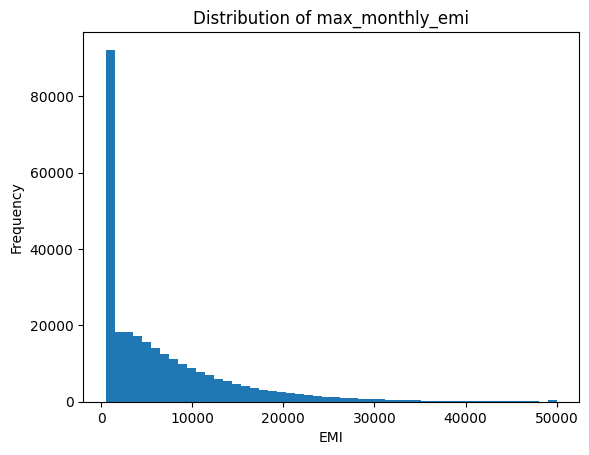

In [54]:
import matplotlib.pyplot as plt

plt.hist(y_train_reg, bins=50)
plt.title("Distribution of max_monthly_emi")
plt.xlabel("EMI")
plt.ylabel("Frequency")
plt.show()

In [55]:
from sklearn.metrics import r2_score

train_pred = xgb_reg.predict(X_train_unscaled)
test_pred = xgb_reg.predict(X_test_unscaled)

train_r2 = r2_score(y_train_reg, train_pred)
test_r2 = r2_score(y_test_reg, test_pred)

print(f"Train R²: {train_r2:.4f}")
print(f"Test R²: {test_r2:.4f}")

Train R²: 0.9832
Test R²: 0.9814


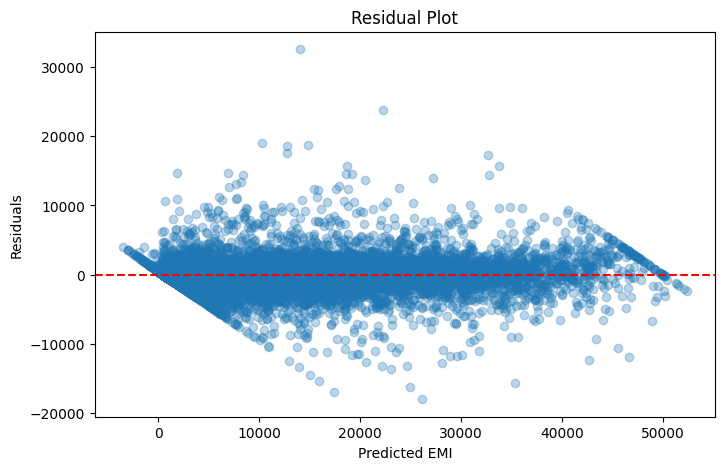

In [56]:
residuals = y_test_reg - test_pred

plt.figure(figsize=(8,5))
plt.scatter(test_pred, residuals, alpha=0.3)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted EMI")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

“MAPE appears relatively high because the dataset contains very small EMI values (around ₹500). Even small absolute errors in these cases lead to large percentage errors. However, R² remains high because the model accurately captures overall variance across the dataset. Therefore, RMSE and R² are more reliable evaluation metrics in this context.”

In [57]:
import pandas as pd
import numpy as np
import joblib

# =========================
# 1. LOAD MODEL + FEATURES
# =========================
model = joblib.load("processed_data/xgb_regressor_final.pkl")
feature_cols = joblib.load("processed_data/reg_feature_columns.pkl")

# =========================
# 2. INPUT
# =========================
input_data = {
 'age': 45, 'years_of_employment': 15,
 'monthly_rent': 0, 'family_size': 2,
 'school_fees': 0, 'college_fees': 0,
 'travel_expenses': 1000, 'groceries_utilities': 3000,
 'other_monthly_expenses': 2000,
 'current_emi_amount': 1000,
 'credit_score': 800,
 'requested_tenure': 48,
 'monthly_salary': 90000,
 'requested_amount': 600000,
 'bank_balance': 500000,
 'gender': 'female',
 'marital_status': 'married',
 'education': 'professional',
 'employment_type': 'government',
 'company_type': 'large_indian',
 'house_type': 'own',
 'existing_loans': 'no',
 'emi_scenario': 'education_emi'
}

df = pd.DataFrame([input_data])

# =========================
# 3. ✅ SAME FEATURE ENGINEERING
# =========================
def engineer_features(df):
    df_new = df.copy()
    
    df_new = df_new.drop(columns=['dependents', 'emergency_fund'], errors='ignore')
    
    expense_cols = [
        'monthly_rent', 'school_fees', 'college_fees',
        'travel_expenses', 'groceries_utilities', 'other_monthly_expenses'
    ]
    df_new['total_expenses'] = df_new[expense_cols].sum(axis=1)
    
    df_new['dti_ratio'] = df_new['current_emi_amount'] / df_new['monthly_salary']
    
    skewed_cols = ['monthly_salary', 'requested_amount', 'bank_balance']
    for col in skewed_cols:
        df_new[f'{col}_log'] = np.log1p(df_new[col])
    
    df_new['loan_to_income'] = (
        df_new['requested_amount_log'] / df_new['monthly_salary_log']
    )
    
    df_new['available_for_emi'] = (
        df_new['monthly_salary'] - df_new['total_expenses'] - df_new['current_emi_amount']
    )
    
    df_new['expense_ratio'] = df_new['total_expenses'] / df_new['monthly_salary']
    
    df_new['emi_capacity'] = df_new['available_for_emi'] * 0.50
    
    df_new['credit_multiplier'] = (df_new['credit_score'] - 300) / 600
    
    df_new['adjusted_capacity'] = (
        df_new['emi_capacity'] * (0.8 + 0.4 * df_new['credit_multiplier'])
    )
    
    df_new['credit_utilization'] = (
        df_new['current_emi_amount'] / (df_new['monthly_salary'] + 1)
    )
    df_new['credit_utilization'] = df_new['credit_utilization'].clip(upper=1.0)
    
    df_new['credit_dti_interaction'] = (
        df_new['credit_score'] * df_new['dti_ratio']
    )
    
    df_new = df_new.drop(columns=skewed_cols)
    
    return df_new

# APPLY SAME PIPELINE
df = engineer_features(df)

# =========================
# 4. ENCODING + ALIGNMENT
# =========================
df = pd.get_dummies(df)
df = df.reindex(columns=feature_cols, fill_value=0)

# =========================
# 5. PREDICT
# =========================
prediction = model.predict(df)

print(f"💰 Predicted Max EMI: ₹{prediction[0]:.2f}")

💰 Predicted Max EMI: ₹26847.37


In [58]:
import joblib

# Save final XGBoost regressor
joblib.dump(xgb_reg, "processed_data/xgb_regressor_final.pkl")

print("✅ Regression model saved successfully")

✅ Regression model saved successfully


In [60]:
y_test_pred = xgb_reg.predict(X_test_unscaled)

test_rmse, test_mae, test_r2, test_mape = evaluate_regression(
    "XGBoost Test",
    xgb_reg,
    X_test_unscaled,
    y_test_reg
)


XGBoost Test Performance:
RMSE: 1052.83
MAE: 467.24
R² Score: 0.9814
MAPE: 16.94%


In [61]:
import json

reg_metrics = {
    "model": "XGBoost Regressor",
    "rmse": test_rmse,
    "mae": test_mae,
    "r2": test_r2
}

with open("processed_data/regression_metrics.json", "w") as f:
    json.dump(reg_metrics, f, indent=4)

print("✅ Metrics saved")

✅ Metrics saved


In [62]:
model = joblib.load("processed_data/xgb_regressor_final.pkl")
print("✅ Loaded model:", type(model))

✅ Loaded model: <class 'xgboost.sklearn.XGBRegressor'>


In [63]:
# Feature columns
joblib.dump(X_train_unscaled.columns.tolist(), "processed_data/reg_feature_columns.pkl")

print("✅ Feature columns saved")

✅ Feature columns saved


In [64]:
import joblib
import pandas as pd

# Load model
model = joblib.load("processed_data/xgb_model.pkl")

# Load data
X_test = pd.read_csv("processed_data/X_test_unscaled.csv")
y_test = pd.read_csv("processed_data/y_test_clf.csv").squeeze()

In [65]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

# Metrics
acc = accuracy_score(y_test, y_pred)
f1_weighted = f1_score(y_test, y_pred, average='weighted')
f1_macro = f1_score(y_test, y_pred, average='macro')

y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
roc_auc = roc_auc_score(y_test_bin, y_prob, multi_class='ovr')

report_dict = classification_report(y_test, y_pred, output_dict=True)

print("✅ Metrics recomputed")

✅ Metrics recomputed


In [66]:
import json

clf_metrics = {
    "model": "XGBoost Classifier",
    "accuracy": float(acc),
    "f1_weighted": float(f1_weighted),
    "f1_macro": float(f1_macro),
    "roc_auc": float(roc_auc),
    "precision_class_1": float(report_dict['1']['precision']),
    "recall_class_1": float(report_dict['1']['recall']),
    "f1_class_1": float(report_dict['1']['f1-score'])
}

with open("processed_data/classification_metrics.json", "w") as f:
    json.dump(clf_metrics, f, indent=4)

print("✅ Classification metrics saved")

✅ Classification metrics saved


In [67]:
import joblib

model = joblib.load("processed_data/xgb_model.pkl")

joblib.dump(model, "processed_data/xgb_classifier_final.pkl")

print("✅ Renamed and saved")

✅ Renamed and saved


In [68]:
import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri("sqlite:///mlflow.db")

In [69]:
mlflow.set_experiment("EMI_Classification")

with mlflow.start_run(run_name="XGBoost_FINAL_SELECTED"):

    mlflow.log_param("model", "XGBoost Classifier")

    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("f1_weighted", f1_weighted)
    mlflow.log_metric("f1_macro", f1_macro)
    mlflow.log_metric("roc_auc", roc_auc)

    mlflow.log_metric("precision_class_1", report_dict['1']['precision'])
    mlflow.log_metric("recall_class_1", report_dict['1']['recall'])

    mlflow.sklearn.log_model(
        joblib.load("processed_data/xgb_classifier_final.pkl"),
        name="model"
    )

print("✅ Classification logged")

2026/04/12 17:32:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Classification logged


In [70]:
mlflow.set_experiment("EMI_Regression")

with mlflow.start_run(run_name="Linear_Regression"):

    mlflow.log_param("model", "Linear Regression")

    mlflow.log_metric("rmse", lr_rmse)
    mlflow.log_metric("mae", lr_mae)
    mlflow.log_metric("r2", lr_r2)

    mlflow.sklearn.log_model(lr_reg, name="model")

2026/04/12 17:32:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [71]:
with mlflow.start_run(run_name="Random_Forest_Regressor"):

    mlflow.log_param("model", "Random Forest")

    mlflow.log_metric("rmse", rf_rmse)
    mlflow.log_metric("mae", rf_mae)
    mlflow.log_metric("r2", rf_r2)

    mlflow.sklearn.log_model(rf_reg, name="model")

2026/04/12 17:32:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [72]:
with mlflow.start_run(run_name="XGBoost_Regressor_FINAL"):

    mlflow.log_param("model", "XGBoost Regressor")

    mlflow.log_metric("rmse", test_rmse)
    mlflow.log_metric("mae", test_mae)
    mlflow.log_metric("r2", test_r2)

    mlflow.sklearn.log_model(
        joblib.load("processed_data/xgb_regressor_final.pkl"),
        name="model"
    )

print("✅ Regression logged")

2026/04/12 17:32:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Regression logged


In [73]:
print(y_train_reg.describe())

count    283347.000000
mean       6757.978650
std        7689.428207
min         500.000000
25%         500.000000
50%        4211.200000
75%        9800.000000
max       50000.000000
Name: max_monthly_emi, dtype: float64
